seed locked to 42
opentargets data loaded from disk
disease: sickle cell disease|efo: MONDO_0011382
targets loaded:20

gene sequences loaded from disk:5
papers loaded from disk:289

cell 1 summary
disease:sickle cell disease (MONDO_0011382)
genes fetched:['HBB', 'BCL11A', 'RRM2B', 'RRM1', 'RRM2']
papers:289
sample:HBB|628 bp|refseq:NM_000518.5


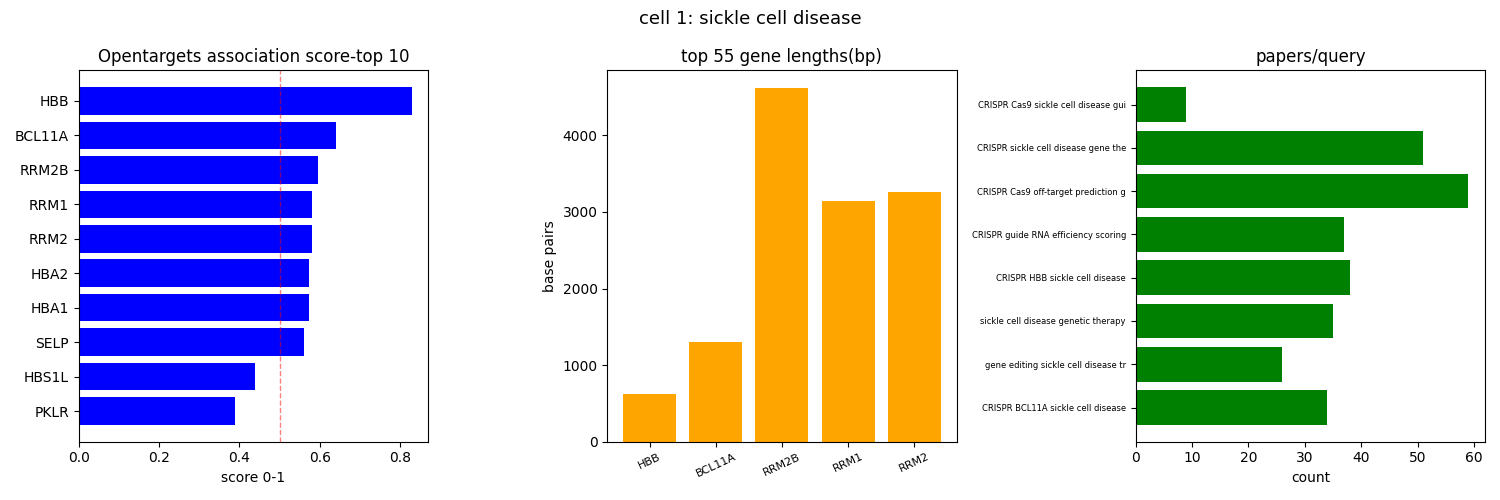


cell 1 done


In [1]:
#cell 1 setup and dataloading/fetching
import os
import re
import gc
import json
import random
import warnings
import time
import requests
from IPython.display import Image,display
#ignoring warnings an setting up env vars
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"]="false"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"]="1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"]="1"
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from Bio import Entrez,SeqIO,Medline
from datasets import disable_caching
disable_caching()

#locking randomness for reproducibility
SEED=42
random.seed(SEED)
np.random.seed(SEED)
print(f"seed locked to {SEED}")
BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
Results_folder=os.path.join(BASE_DIR,"Results")
DATA_DIR=os.path.join(BASE_DIR,"Data")
CACHE_DIR=os.path.join(BASE_DIR,"hf_cache")
os.makedirs(Results_folder,exist_ok=True)
os.makedirs(DATA_DIR,exist_ok=True)
os.makedirs(CACHE_DIR,exist_ok=True)
os.environ["TRANSFORMERS_CACHE"]=CACHE_DIR
os.environ["HF_HOME"]=CACHE_DIR
Entrez.email="ishan.sharma.ug24@nsut.ac.in"

#change this to test any disease u wanna
DISEASE_QUERY="sickle cell anemia"
OT_ENDPOINT="https://api.platform.opentargets.org/api/v4/graphql"
TOP_N_GENES=55

#find disease efo(Experimental factor ontology)id from ot
def search_disease(disease_name):
    query="""
    query searchDisease($q:String!){
      search(queryString:$q,entityNames:["disease"]) {
        hits{id name entity}}}"""
    resp=requests.post(
        OT_ENDPOINT,
        json={"query":query,"variables":{"q":disease_name}},
        headers={"Content-Type":"application/json"},
        timeout=30
    )
    resp.raise_for_status()
    hits=resp.json()["data"]["search"]["hits"]
    diseases=[h for h in hits if h["entity"]=="disease"]
    if not diseases:
        raise ValueError(f"no disease found for: {disease_name}")
    return diseases[0]["id"],diseases[0]["name"]

#fetching associated gene targets with scores
def get_disease_targets(efo_id,n=20):
    query="""
    query diseaseTargets($diseaseId: String!, $size: Int!) {
      disease(efoId: $diseaseId) {
        id
        name
        associatedTargets(page: {index: 0, size: $size}) {
          rows {
            target {
              id
              approvedSymbol
              approvedName
            }
            score
          }
        }
      }
    }"""
    resp=requests.post(
        OT_ENDPOINT,
        json={"query":query,"variables":{"diseaseId":efo_id,"size":n}},
        headers={"Content-Type":"application/json"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()["data"]["disease"]

#fetching refseq id from ncbi
def get_refseq(gene_symbol):
    try:
        handle=Entrez.esearch(
            db="nucleotide",
            term=f'"{gene_symbol}"[Gene Name] AND "Homo sapiens"[Organism] AND refseq[filter]',
            retmax=10,
            sort="relevance"
        )
        results=Entrez.read(handle)
        handle.close()
        ids=results["IdList"]
        if not ids:
            return None
        time.sleep(0.4)
        #get NM_ accession from ncbi
        handle=Entrez.efetch(db="nucleotide",id=",".join(ids[:8]),rettype="acc",retmode="text")
        raw=handle.read().strip()
        handle.close()
        time.sleep(0.4)
        nm_accs=[a.strip() for a in raw.split('\n') if a.strip().startswith("NM_")]
        return nm_accs[0] if nm_accs else None
    except Exception as e:
        print(f"refseq lookup failed {gene_symbol}:{e}")
        return None

#fetch sequence from ncbi
def fetch_sequence(refseq_id,gene_name):
    try:
        handle=Entrez.efetch(db="nucleotide",id=refseq_id,rettype="fasta",retmode="text")
        record=SeqIO.read(handle,"fasta")
        handle.close()
        return {"gene":gene_name,"refseq":refseq_id,
                "sequence":str(record.seq),"length":len(record.seq)}
    except Exception as e:
        print(f"sequence fetch failed {gene_name}:{e}")
        return None

#run ot query and freeze
OT_PATH=os.path.join(DATA_DIR,"opentargets_results.json")
if os.path.exists(OT_PATH):
    with open(OT_PATH,encoding="utf-8") as f:
        ot_data=json.load(f)
    print(f"opentargets data loaded from disk")
    print(f"disease: {ot_data['disease_name']}|efo: {ot_data['efo_id']}")
    print(f"targets loaded:{len(ot_data['targets'])}")
else:
    print(f"querying opentargets: {DISEASE_QUERY}")
    efo_id,disease_name=search_disease(DISEASE_QUERY)
    print(f"matched: {disease_name}|efo: {efo_id}")
    raw=get_disease_targets(efo_id,n=20)
    rows=raw["associatedTargets"]["rows"]
    targets=[]
    for r in rows:
        t=r["target"]
        targets.append({
            "gene_symbol":t["approvedSymbol"],
            "gene_name":t["approvedName"],
            "ensembl_id":t["id"],
            "association_score":round(r["score"],4),
        })
    ot_data={
        "disease_query":DISEASE_QUERY,
        "disease_name":disease_name,
        "efo_id":efo_id,
        "targets":targets
    }
    with open(OT_PATH,"w",encoding="utf-8") as f:
        json.dump(ot_data,f,ensure_ascii=False,indent=2)
    print(f"opentargets frozen: {OT_PATH}")
    print(f"\ntop 10 targets:")
    for i,t in enumerate(targets[:10],1):
        print(f"[{i}] {t['gene_symbol']}|assoc:{t['association_score']}")

#fetch ncbi sequences for top n genes
SEQ_PATH=os.path.join(DATA_DIR,"gene_sequences.json")
if os.path.exists(SEQ_PATH):
    with open(SEQ_PATH,encoding="utf-8") as f:
        gene_sequences=json.load(f)
    print(f"\ngene sequences loaded from disk:{len(gene_sequences)}")
else:
    print(f"\nfetching sequences for top {TOP_N_GENES} genes")
    gene_sequences={}
    for t in ot_data["targets"][:TOP_N_GENES]:
        sym=t["gene_symbol"]
        print(f"{sym}: ",end="")
        refseq=get_refseq(sym)
        if not refseq:
            print("no NM_ refseq found,skipping")
            continue
        print(f"refseq={refseq}|",end="")
        result=fetch_sequence(refseq,sym)
        if result:
            result["association_score"]=t["association_score"]
            gene_sequences[sym]=result
            print(f"{result['length']} bp")
        time.sleep(0.4)
    with open(SEQ_PATH,"w",encoding="utf-8") as f:
        json.dump(gene_sequences,f,ensure_ascii=False,indent=2)
    print(f"sequences frozen:")

#disease-specific pubmed fetch
PAPERS_PATH=os.path.join(DATA_DIR,"crispr_papers.json")
disease_term=ot_data["disease_name"]
PUBMED_QUERIES=[
    f"CRISPR Cas9 {disease_term} guide RNA design",
    f"CRISPR {disease_term} gene therapy",
    f"gene editing {disease_term} treatment",
    "CRISPR guide RNA efficiency scoring sgRNA",
    "CRISPR Cas9 off-target prediction genome",
    "sgRNA design rules GC content seed region",
    f"{disease_term} genetic therapy clinical trial",
]
##pubmed fetch,extra queries for top 3 genes
for t in ot_data["targets"][:3]:
    PUBMED_QUERIES.append(f"CRISPR {t['gene_symbol']} {disease_term}")
def fetch_pubmed_papers(query,max_results=60):
    search_handle=Entrez.esearch(db="pubmed",term=query,retmax=max_results,sort="relevance")
    search_results=Entrez.read(search_handle)
    search_handle.close()
    ids=search_results["IdList"]
    if not ids:
        return []
    time.sleep(0.4)
    fetch_handle=Entrez.efetch(db="pubmed",id=",".join(ids),rettype="medline",retmode="text")
    records=list(Medline.parse(fetch_handle))
    fetch_handle.close()
    time.sleep(0.4)
    papers=[]
    for r in records:
        title=r.get("TI","").strip()
        abstract=r.get("AB","").strip()
        if not abstract or len(abstract)<100:
            continue
        papers.append({
            "title":title,
            "abstract":abstract[:1200],
            "authors":r.get("AU",[])[:3],
            "year":r.get("DP","")[:4],
            "query":query,
            "source":"PubMed"
        })
    return papers

if os.path.exists(PAPERS_PATH):
    with open(PAPERS_PATH,encoding="utf-8") as f:
        papers=json.load(f)
    print(f"papers loaded from disk:{len(papers)}")
else:
    print(f"\nfetching pubmed papers for {disease_term}")
    all_papers=[]
    seen_titles=set()
    for query in PUBMED_QUERIES:
        print(f"'{query[:50]}': ",end="")
        try:
            results=fetch_pubmed_papers(query,max_results=60)
            added=0
            for p in results:
                if p["title"] not in seen_titles and p["title"]:
                    seen_titles.add(p["title"])
                    all_papers.append(p)
                    added+=1
            print(f"{added}")
        except Exception as e:
            print(f"failed ({e})")
    random.shuffle(all_papers)
    papers=all_papers
    print(f"\ntotal unique papers: {len(papers)}")
    with open(PAPERS_PATH,"w",encoding="utf-8") as f:
        json.dump(papers,f,ensure_ascii=False,indent=2)
    print(f"papers frozen:{PAPERS_PATH}")

#summary/check
print(f"\ncell 1 summary")
print(f"disease:{ot_data['disease_name']} ({ot_data['efo_id']})")
print(f"genes fetched:{list(gene_sequences.keys())}")
print(f"papers:{len(papers)}")
if gene_sequences:
    s=list(gene_sequences.values())[0]
    print(f"sample:{s['gene']}|{s['length']} bp|refseq:{s['refseq']}")

#visualisation
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle(f"cell 1: {ot_data['disease_name']}",fontsize=13)
top10=ot_data["targets"][:10]
axes[0].barh([t["gene_symbol"] for t in top10][::-1],[t["association_score"] for t in top10][::-1],color="blue")
axes[0].set_title("Opentargets association score-top 10")
axes[0].set_xlabel("score 0-1")
axes[0].axvline(x=0.5,color="red",linestyle="--",linewidth=1,alpha=0.5)
if gene_sequences:
    seq_genes=list(gene_sequences.keys())
    axes[1].bar(seq_genes,[gene_sequences[g]["length"] for g in seq_genes],color="orange")
    axes[1].set_title(f"top {TOP_N_GENES} gene lengths(bp)")
    axes[1].set_ylabel("base pairs")
    axes[1].tick_params(axis='x',rotation=25,labelsize=8)
query_counts={}
for p in papers:
    q=p["query"][:35]
    query_counts[q]=query_counts.get(q,0)+1
axes[2].barh(list(query_counts.keys()),list(query_counts.values()),color="green")
axes[2].set_title("papers/query")
axes[2].set_xlabel("count")
axes[2].tick_params(axis='y',labelsize=6)
plt.tight_layout()
plot_out=os.path.join(Results_folder,"cell1_overview.png")
plt.savefig(plot_out,dpi=100)
plt.close()
display(Image(filename=plot_out))
gc.collect()
print("\ncell 1 done")

disease: sickle cell disease
candidates loaded:20

top 5 genes:
[1] HBB|score:0.8287|hemoglobin subunit beta
[2] BCL11A|score:0.6414|BCL11 transcription factor A
[3] RRM2B|score:0.5946|ribonucleotide reductase regulatory TP53 inducible subunit M2B
[4] RRM1|score:0.5813|ribonucleotide reductase catalytic subunit M1
[5] RRM2|score:0.5813|ribonucleotide reductase regulatory subunit M2

ranked genes loaded from disk


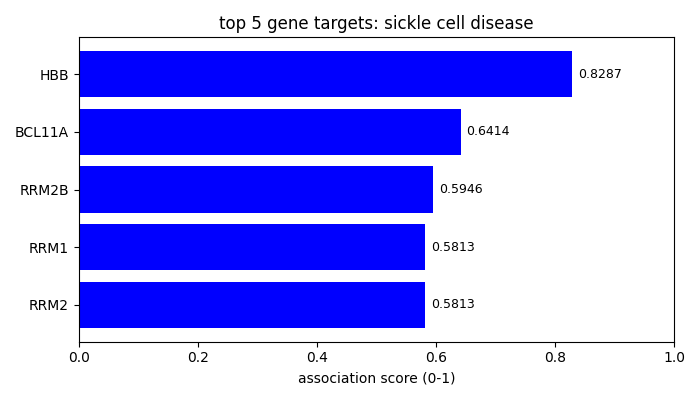

cell 2 done


In [2]:
#gene ranking from ot results
import os,json
import matplotlib.pyplot as plt
BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
RESULTS_DIR=os.path.join(BASE_DIR,"Results")
TOP_N=5
OT_PATH=os.path.join(DATA_DIR,"opentargets_results.json")
RANKED_GENES_PATH=os.path.join(DATA_DIR,"ranked_genes.json")
#load ot results
with open(OT_PATH,"r",encoding="utf-8") as f:
    ot_data=json.load(f)
disease_name=ot_data["disease_name"]
targets=ot_data["targets"]
print(f"disease: {disease_name}")
print(f"candidates loaded:{len(targets)}")
#rank by association score
ranked=sorted(targets,key=lambda x:x["association_score"],reverse=True)
top_genes=ranked[:TOP_N]
print(f"\ntop {TOP_N} genes:")
for i,g in enumerate(top_genes,1):
    print(f"[{i}] {g['gene_symbol']}|score:{g['association_score']}|{g['gene_name']}")
#freezing
if not os.path.exists(RANKED_GENES_PATH):
    with open(RANKED_GENES_PATH,"w",encoding="utf-8") as f:
        json.dump({"disease_name":disease_name,"top_genes":top_genes},f,indent=2)
    print(f"\nranked genes frozen:{RANKED_GENES_PATH}")
else:
    print(f"\nranked genes loaded from disk")

#visualisation
symbols=[g["gene_symbol"] for g in top_genes]
scores=[g["association_score"] for g in top_genes]
fig,ax=plt.subplots(figsize=(7,4))
bars=ax.barh(symbols,scores,color="blue")
ax.set_xlabel("association score (0-1)")
ax.set_title(f"top {TOP_N} gene targets: {disease_name}")
ax.set_xlim(0,1)
for bar,score in zip(bars,scores):
    ax.text(bar.get_width()+0.01,bar.get_y()+bar.get_height()/2,
            f"{score:.4f}",va="center",fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plot_out=os.path.join(RESULTS_DIR,"cell2_ranked_genes.png")
plt.savefig(plot_out,dpi=100)
plt.close()
display(Image(filename=plot_out))
print("cell 2 done")

doench dataset loaded from disk:5310 rows

training xgboost on doench 2016 experimental scores....,
xgboost trained|r2:0.2769|features:93

top gene:HBB|refseq:NM_000518.5|length:628 bp
candidates found:52 NGG sites
after filter (>=0.4):42 candidates

top 10 guides:
[1] AGTCTGCCGTTACTGCCCTG|score:0.8561|pos:75(11.94%)
[2] TAAGTCCAACTACTAAACTG|score:0.8513|pos:541(86.15%)
[3] TCTGCCGTTACTGCCCTGTG|score:0.7491|pos:77(12.26%)
[4] GCACTGTGACAAGCTGCACG|score:0.7016|pos:325(51.75%)
[5] GGCTGCCTATCAGAAAGTGG|score:0.6907|pos:433(68.95%)
[6] TATGGGCAACCCTAAGGTGA|score:0.6854|pos:214(34.08%)
[7] AAGTCCAACTACTAAACTGG|score:0.6792|pos:542(86.31%)
[8] TGGTCTACCCTTGGACCCAG|score:0.6654|pos:150(23.89%)
[9] GCAGGCTGCCTATCAGAAAG|score:0.6501|pos:430(68.47%)
[10] CATGGTGCATCTGACTCCTG|score:0.6422|pos:49(7.8%)

ranked guides loaded from disk


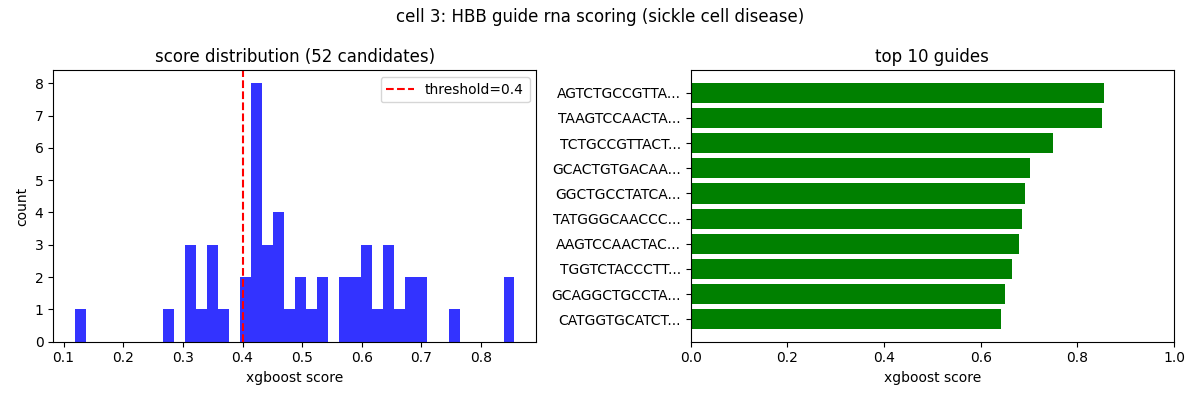

cell 3 done


In [3]:
#pam scan+xgboost scorin
import io
import pandas as pd
import requests
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import itertools

BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
RESULTS_DIR=os.path.join(BASE_DIR,"Results")
DOENCH_URL="https://raw.githubusercontent.com/MicrosoftResearch/Azimuth/refs/heads/master/azimuth/data/FC_plus_RES_withPredictions.csv"
DOENCH_PATH=os.path.join(DATA_DIR,"doench2016.csv")
GUIDES_PATH=os.path.join(DATA_DIR,"ranked_guides.json")
SCORE_THRESHOLD=0.4
TOP_K=10

#feat extrac from 30mer seq
def extract_features(seq30):
    #extract 20nt guide from pos 4-24 of the 30mer context
    guide=seq30[4:24] if len(seq30)>=24 else seq30[:20]
    guide=guide.ljust(20,'N')
    #seed region last 12nt before PAM cas9 checks here
    seed=guide[-12:]
    gc=lambda s:(s.count('G')+s.count('C'))/max(len(s),1)
    feats={
        #gc content of 30mer
        "gc_30mer":round(gc(seq30),4),
        #gc content of 20nt guide optimal rang=40-70%
        "gc_20mer":round(gc(guide),4),
        #gc content of seed region high=better stability
        "gc_seed":round(gc(seed),4),
        #poly-T penalty
        "poly_t":1 if 'TTTT' in guide else 0,
        #base freqs across guides
        "a_freq":round(guide.count('A')/20,4),
        "t_freq":round(guide.count('T')/20,4),
        "g_freq":round(guide.count('G')/20,4),
        "c_freq":round(guide.count('C')/20,4),
        #gc clamp: G/C at last pos before PAM= good stability
        "gc_clamp":1 if guide[-1] in ('G','C') else 0,
        #homopolymer= longest continuous run of 1 base long=worse
        "homopolymer":max(len(list(g)) for _,g in itertools.groupby(guide)),
        #dinucleotide repeats
        "dinuc_repeat":sum(guide[i:i+2]==guide[i+2:i+4] for i in range(0,18,2)),
        #unique dinucleotides: few unique=higher off target risk
        "unique_dinucs":len(set(guide[i:i+2] for i in range(19))),
        #seed unique bases: low diversity here=off targer risk
        "seed_unique_bases":len(set(seed)),
    }
    #pos encoding=20 pos*4 bases=80 feats
    for pos in range(20):
        base=guide[pos] if pos<len(guide) else 'N'
        for b in ['A','T','G','C']:
            feats[f"p{pos}_{b}"]=1 if base==b else 0
    return feats

FEATURE_COLS=list(extract_features("N"*30).keys())
#load doench dataset
if os.path.exists(DOENCH_PATH):
    df=pd.read_csv(DOENCH_PATH)
    print(f"doench dataset loaded from disk:{len(df)} rows")
else:
    print("fetching doench 2016 dataset...")
    resp=requests.get(DOENCH_URL,timeout=30)
    resp.raise_for_status()
    df=pd.read_csv(io.StringIO(resp.text))
    df.to_csv(DOENCH_PATH,index=False)
    print(f"doench dataset frozen: {len(df)} rows")

#training xgboost on experimental eff scores
print("\ntraining xgboost on doench 2016 experimental scores....,")
df=df.dropna(subset=["30mer","score_drug_gene_rank"])
df["30mer"]=df["30mer"].str.upper()
x=pd.DataFrame([extract_features(s) for s in df["30mer"]])
y=df["score_drug_gene_rank"].values
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=XGBRegressor(n_estimators=200,max_depth=4,learning_rate=0.05,random_state=42,verbosity=0)
model.fit(x_train,y_train)
r2=r2_score(y_test,model.predict(x_test))
print(f"xgboost trained|r2:{r2:.4f}|features:{len(FEATURE_COLS)}")

#load top gene+seq
with open(os.path.join(DATA_DIR,"ranked_genes.json"),encoding="utf-8") as f:
    ranked=json.load(f)
top_gene=ranked["top_genes"][0]["gene_symbol"]
disease_name=ranked["disease_name"]
with open(os.path.join(DATA_DIR,"gene_sequences.json"),encoding="utf-8") as f:
    seqs=json.load(f)
if top_gene not in seqs:
    print(f"sequence not found for{top_gene}, using 1st available")
    top_gene=list(seqs.keys())[0]
seq_data=seqs[top_gene]
sequence=seq_data["sequence"].upper()
refseq=seq_data["refseq"]
gene_len=len(sequence)
print(f"\ntop gene:{top_gene}|refseq:{refseq}|length:{gene_len} bp")

#pam scan
def find_candidates(seq,gene_name):
    candidates=[]
    for i in range(len(seq)-22):
        if seq[i+21]=='G' and seq[i+22]=='G':
            guide=seq[i:i+20]
            if len(guide)==20 and all(c in 'ACGT' for c in guide):
                start=max(0,i-4)
                ctx_before=seq[start:i]
                ctx_after=seq[i+20:i+26] if i+26<=len(seq) else (seq[i+20:]+("N"*(i+26-len(seq))))
                seq30=('N'*(4-len(ctx_before)))+ctx_before+guide+ctx_after
                seq30=seq30[:30].ljust(30,'N')
                candidates.append({
                    "gene":gene_name,
                    "guide_sequence":guide,
                    "position":i,
                    "pam":seq[i+20:i+23],
                    "seq30":seq30,
                })
    return candidates
candidates=find_candidates(sequence,top_gene)
print(f"candidates found:{len(candidates)} NGG sites")

#scoring with xgboost
x_cand=pd.DataFrame([extract_features(c["seq30"]) for c in candidates])
scores=model.predict(x_cand)
for i,c in enumerate(candidates):
    c["xgb_score"]=round(float(scores[i]),4)
    c["position_pct"]=round(c["position"]/gene_len*100,2)

filtered=[c for c in candidates if c["xgb_score"]>=SCORE_THRESHOLD]
ranked_guides=sorted(filtered,key=lambda x:x["xgb_score"],reverse=True)[:TOP_K]
print(f"after filter (>={SCORE_THRESHOLD}):{len(filtered)} candidates")
print(f"\ntop {TOP_K} guides:")
for i,g in enumerate(ranked_guides,1):
    print(f"[{i}] {g['guide_sequence']}|score:{g['xgb_score']}|pos:{g['position']}({g['position_pct']}%)")

#freeze
if not os.path.exists(GUIDES_PATH):
    with open(GUIDES_PATH,"w",encoding="utf-8") as f:
        json.dump({"disease":disease_name,"gene":top_gene,"refseq":refseq,
                   "model":"xgboost_doench2016","guides":ranked_guides},f,indent=2)
    print(f"\nranked guides frozen:{GUIDES_PATH}")
else:
    print(f"\nranked guides loaded from disk")

#visualisation
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle(f"cell 3: {top_gene} guide rna scoring ({disease_name})",fontsize=12)
all_scores=[c["xgb_score"] for c in candidates]
axes[0].hist(all_scores,bins=40,color="blue",alpha=0.8)
axes[0].axvline(x=SCORE_THRESHOLD,color="red",linestyle="--",linewidth=1.5,label=f"threshold={SCORE_THRESHOLD}")
axes[0].set_xlabel("xgboost score")
axes[0].set_ylabel("count")
axes[0].set_title(f"score distribution ({len(candidates)} candidates)")
axes[0].legend()
top_seqs=[g["guide_sequence"][:12]+"..." for g in ranked_guides]
top_scores=[g["xgb_score"] for g in ranked_guides]
axes[1].barh(top_seqs[::-1],top_scores[::-1],color="green")
axes[1].set_xlabel("xgboost score")
axes[1].set_title(f"top {TOP_K} guides")
axes[1].set_xlim(0,1)
plt.tight_layout()
plot_out=os.path.join(RESULTS_DIR,"cell3_guide_scores.png")
plt.savefig(plot_out,dpi=100)
plt.close()
display(Image(filename=plot_out))
print("cell 3 done")

In [4]:
#llm baseline just disease name in, no rag
import torch
from transformers import AutoTokenizer,AutoModelForCausalLM
warnings.filterwarnings("ignore")

BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
RESULTS_DIR=os.path.join(BASE_DIR,"Results")
CACHE_DIR=r"C:\Users\user\.cache\huggingface\hub"
LLM_BASELINE_PATH=os.path.join(DATA_DIR,"llm_baseline_output.json")
MODEL_ID="Qwen/Qwen2.5-7B-Instruct"
random.seed(42)
torch.manual_seed(42)

#load disease+top genes from frozen data
with open(os.path.join(DATA_DIR,"ranked_genes.json"),"r") as f:
    ranked_data=json.load(f)
disease_name=ranked_data["disease_name"]
top_genes=[g["gene_symbol"] for g in ranked_data["top_genes"]]

#load top guide per gene from ranked_guides.json
with open(os.path.join(DATA_DIR,"ranked_guides.json"),"r") as f:
    guides_data=json.load(f)

#query llm sees
QUERY=(
    f"I am designing a CRISPR-Cas9 experiment to treat {disease_name}. "
    f"What genes would you target and why? "
    f"For each gene, suggest a guide RNA sequence (20nt, NGG PAM) "
    f"and explain what makes it likely to be efficient."
)
if os.path.exists(LLM_BASELINE_PATH):
    print("loading frozen llm baseline output")
    with open(LLM_BASELINE_PATH,"r") as f:
        baseline_result=json.load(f)
    llm_response=baseline_result["llm_response"]
    print("llm baseline(no rag context):")
    print(llm_response[:800],"...")
else:
    print(f"loading {MODEL_ID}...")
    tokenizer=AutoTokenizer.from_pretrained(
        MODEL_ID,
        cache_dir=CACHE_DIR,
        trust_remote_code=True
    )
    model=AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        cache_dir=CACHE_DIR,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    model.eval()
    messages=[{"role":"system","content":"You are a computational biology expert specializing in CRISPR-Cas9 guide RNA design."},{"role":"user","content":QUERY}]
    text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer([text],return_tensors="pt").to(model.device)
    with torch.no_grad():
        out=model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    generated=out[0][inputs["input_ids"].shape[1]:]
    llm_response=tokenizer.decode(generated,skip_special_tokens=True)
    baseline_result={
        "disease":disease_name,
        "query":QUERY,
        "llm_response":llm_response,
        "model":MODEL_ID,
        "context_used":"none"
    }
    with open(LLM_BASELINE_PATH,"w") as f:
        json.dump(baseline_result,f,indent=2)
    print("frozen llm_baseline_output.json")
    del model,tokenizer,inputs,out
    gc.collect()
    torch.cuda.empty_cache()
    print("\nllm baseline (no rag context):")
    print(llm_response[:800],"...")
print(f"\ndisease: {disease_name}")
print(f"ot top genes: {top_genes}")
print("baseline saved")

loading frozen llm baseline output
llm baseline(no rag context):
Sickle cell disease is caused by a single nucleotide polymorphism (SNP) in the *HBB* (hemoglobin beta) gene, which results in a valine being replaced with a glutamic acid at the sixth position of the beta-globin chain. This mutation leads to the formation of sickled red blood cells, causing various complications. To correct this condition using CRISPR-Cas9, you would need to target the *HBB* gene and introduce a correction that replaces the mutated codon with the wild-type codon.

### Targeting the HBB Gene

#### 1. **Gene Location and Mutation:**
   - The *HBB* gene is located on chromosome 11p15.5.
   - The SNP responsible for sickle cell disease is at position 30 of the beta-globin mRNA, which corresponds to position 6 of the beta-globin protein.

#### 2. **Guide RNA Design:**
   - To c ...

disease: sickle cell disease
ot top genes: ['HBB', 'BCL11A', 'RRM2B', 'RRM1', 'RRM2']
baseline saved


In [5]:
#cell 5 rag+llm ot+pubmed+ml guide context
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from transformers import AutoTokenizer,AutoModelForCausalLM
BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
RESULTS_DIR=os.path.join(BASE_DIR,"Results")
CACHE_DIR=r"C:\Users\user\.cache\huggingface\hub"
RAG_OUTPUT_PATH=os.path.join(DATA_DIR,"rag_output.json")
MODEL_ID="Qwen/Qwen2.5-7B-Instruct"
TOP_K=6
#loading frozen data
with open(os.path.join(DATA_DIR,"ranked_genes.json"),encoding="utf-8") as f:
    ranked_data=json.load(f)
with open(os.path.join(DATA_DIR,"ranked_guides.json"),encoding="utf-8") as f:
    guides_data=json.load(f)
with open(os.path.join(DATA_DIR,"crispr_papers.json"),encoding="utf-8") as f:
    papers=json.load(f)
disease_name=ranked_data["disease_name"]
top_genes=ranked_data["top_genes"]

#opentargets hardcoded doesnt go into chromadb
ot_context="OpenTargets therapeutic targets for "+disease_name+":\n"
for g in top_genes:
    ot_context+=f"{g['gene_symbol']} ({g['gene_name']}): association_score={g['association_score']}\n"

#consolidated guide doc ranked by xgb score
guide_lines="ML-ranked guide RNAs for "+guides_data["gene"]+" (XGBoost, Doench 2016, ranked by efficiency):\n"
for i,g in enumerate(guides_data["guides"],1):
    guide_lines+=(
        f"{i}. {g['guide_sequence']}|score:{g['xgb_score']} | "
        f"pos:{g['position']}({g['position_pct']}%)|PAM:{g['pam']}\n"
    )
#pubmed docs
pubmed_docs=[]
for p in papers[:30]:
    title=p.get("title","")
    abstract=p.get("abstract","") or p.get("summary","")
    if not title:
        continue
    content=f"Title: {title}\nAbstract: {abstract[:400]}" if abstract else f"Title: {title}"
    pubmed_docs.append(Document(page_content=content,metadata={"source":"pubmed"}))

#chromadb pubmed only
all_docs=pubmed_docs
print(f"chromadb documents:{len(all_docs)} pubmed only")

#building vector store
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    cache_folder=CACHE_DIR
)
vectorstore=Chroma.from_documents(all_docs,embeddings)
retriever=vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k":TOP_K,"fetch_k":20}
)
print(f"vector store ready,mmr retrieval k={TOP_K}")

#retrieve
QUERY=(
    f"I am designing a CRISPR-Cas9 experiment to treat {disease_name}. "
    f"What genes would you target and why? "
    f"For each gene, suggest a guide RNA sequence (20nt, NGG PAM) "
    f"and explain what makes it likely to be efficient."
)
retrieved=retriever.invoke(QUERY)
mmr_context="\n\n".join([f"[{d.metadata['source'].upper()}]\n{d.page_content}" for d in retrieved])
print(f"\nretrieved {len(retrieved)} chunks via mmr:")
for d in retrieved:
    print(f"[{d.metadata['source']}] {d.page_content[:60]}...")

#built final context bloc
full_context=(
    f"[OPENTARGETS - VALIDATED TARGETS]\n{ot_context}\n"
    f"[ML PIPELINE - RANKED GUIDE RNAs]\n{guide_lines}\n"
    f"[LITERATURE - MMR RETRIEVED]\n{mmr_context}"
)
if os.path.exists(RAG_OUTPUT_PATH):
    with open(RAG_OUTPUT_PATH,encoding="utf-8") as f:
        rag_result=json.load(f)
    rag_response=rag_result["rag_response"]
else:
    print(f"\nloading {MODEL_ID}...")
    tokenizer=AutoTokenizer.from_pretrained(MODEL_ID,cache_dir=CACHE_DIR,trust_remote_code=True)
    model=AutoModelForCausalLM.from_pretrained(
        MODEL_ID,cache_dir=CACHE_DIR,
        dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    model.eval()
    prompt=(
        f"You are a CRISPR-Cas9 guide RNA design expert."
        f"Use the following pipeline data to answer the question."
        f"Prioritize the highest scored guide RNAs from the ML pipeline.\n\n"
        f"[CONTEXT]\n{full_context}\n[/CONTEXT]\n\n"
        f"Question: {QUERY}"
    )
    messages=[
    {"role":"system","content":"You are a computational biology expert specializing in CRISPR-Cas9 guide RNA design. Always ground your answer in the provided context. When recommending guide RNAs, cite the highest scored ones first."},{"role":"user","content":prompt}]
    text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer([text],return_tensors="pt").to(model.device)
    with torch.no_grad():
        out=model.generate(
            **inputs,
            max_new_tokens=600,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    generated=out[0][inputs["input_ids"].shape[1]:]
    rag_response=tokenizer.decode(generated,skip_special_tokens=True)
    rag_result={
        "disease":disease_name,
        "query":QUERY,
        "retrieved_chunks":[{"source":d.metadata["source"],"content":d.page_content} for d in retrieved],
        "ot_context":ot_context,
        "rag_response":rag_response,
        "model":MODEL_ID,
        "context_used":"opentargets+pubmed+ml_pipeline",
        "top_k":TOP_K}
    
    with open(RAG_OUTPUT_PATH,"w",encoding="utf-8") as f:
        json.dump(rag_result,f,indent=2,ensure_ascii=False)
    print("frozen rag_output.json")
    del model,tokenizer,inputs,out
    gc.collect()
    torch.cuda.empty_cache()
print("\nrag response (with context):")
print(rag_response[:800],"...")
print("\ncell 5 done")

chromadb documents:30 pubmed only


C:\Users\user\AppData\Local\Temp\ipykernel_6412\2335105949.py:50: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings=HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 39942.06it/s]


vector store ready,mmr retrieval k=6

retrieved 6 chunks via mmr:
[pubmed] Title: Transformative CRISPR-Cas9 Technologies: A Review of ...
[pubmed] Title: Off-target interactions in the CRISPR-Cas9 Machinery:...
[pubmed] Title: Efficient prioritization of CRISPR screen hits by acc...
[pubmed] Title: Custom CRISPR-Cas9 PAM variants via scalable engineer...
[pubmed] Title: Structural insights into target detection by the S. m...
[pubmed] Title: Genome editing in the edible fungus Poria cocos using...

rag response (with context):
For treating sickle cell disease (SCD), targeting the HBB gene is the most promising approach due to its direct involvement in the production of abnormal hemoglobin. Below are the recommended guide RNA sequences for the HBB gene, based on the highest scored guide RNAs from the ML pipeline:

1. **Guide RNA Sequence**: AGTCTGCCGTTACTGCCCTG
   - **Score**: 0.8752
   - **Position**: 75 (11.94%)
   - **PAM**: TGG
   - **Efficiency**: This guide RNA has the highest sc

In [6]:
#cell 6: 8 disease inference
BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
CACHE_DIR=r"C:\Users\user\.cache\huggingface\hub"
MULTI_DIR=os.path.join(DATA_DIR,"multi_disease")
os.makedirs(MULTI_DIR,exist_ok=True)
MODEL_ID="Qwen/Qwen2.5-7B-Instruct"
TOP_K=6
SCORE_THRESHOLD=0.4
TOP_GUIDES=10
DISEASES=[
    {"disease":"sickle cell anemia","expected_gene":"HBB"},
    {"disease":"HIV infection","expected_gene":"CCR5"},
    {"disease":"Huntington's disease","expected_gene":"HTT"},
    {"disease":"Duchenne muscular dystrophy","expected_gene":"DMD"},
    {"disease":"cystic fibrosis","expected_gene":"CFTR"},
    {"disease":"breast cancer","expected_gene":"BRCA1"},
    {"disease":"Leber congenital amaurosis","expected_gene":"CEP290"},
    {"disease":"chronic myeloid leukemia","expected_gene":"BCR"},]

def build_ot_context(top_genes,disease_name):
    ctx=f"OpenTargets therapeutic targets for {disease_name}:\n"
    for g in top_genes:
        ctx+=f"{g['gene_symbol']} ({g['gene_name']}): association_score={g['association_score']}\n"
    return ctx
def build_guide_lines(guides_data):
    lines=f"ML-ranked guide RNAs for {guides_data['gene']} (XGBoost, Doench 2016, ranked by efficiency):\n"
    for i,g in enumerate(guides_data["guides"],1):
        lines+=(
            f"{i}.{g['guide_sequence']} | score:{g['xgb_score']}|"
            f"pos:{g['position']}({g['position_pct']}%) | PAM:{g['pam']}\n")
    return lines
def build_pubmed_docs(papers):
    docs=[]
    for p in papers[:30]:
        title=p.get("title","")
        abstract=p.get("abstract","") or p.get("summary","")
        if not title:
            continue
        content=f"Title:{title}\nAbstract: {abstract[:400]}" if abstract else f"Title:{title}"
        docs.append(Document(page_content=content,metadata={"source":"pubmed"}))
    return docs
def generate_response(model,tokenizer,messages,max_new_tokens=600,temperature=0.7):
    text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer([text],return_tensors="pt").to(model.device)
    with torch.no_grad():
        out=model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    generated=out[0][inputs["input_ids"].shape[1]:]
    response=tokenizer.decode(generated,skip_special_tokens=True)
    del inputs,out
    return response
QUERY_TEMPLATE=(
    "I am designing a CRISPR-Cas9 experiment to treat {disease}. "
    "What genes would you target and why? "
    "For each gene, suggest a guide RNA sequence (20nt, NGG PAM) "
    "and explain what makes it likely to be efficient."
)

#load model onxe for all 8 
print(f"loading {MODEL_ID}...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_ID,cache_dir=CACHE_DIR,trust_remote_code=True)
model=AutoModelForCausalLM.from_pretrained(
    MODEL_ID,cache_dir=CACHE_DIR,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print("model loaded\n")
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    cache_folder=CACHE_DIR
)
for entry in DISEASES:
    disease_name=entry["disease"]
    expected_gene=entry["expected_gene"]
    slug=disease_name.lower().replace(" ","_").replace("'","")
    out_path=os.path.join(MULTI_DIR,f"{slug}.json")
    if os.path.exists(out_path):
        print(f"[{expected_gene}] frozen:skipping")
        continue
    print(f"\n[{expected_gene}] processing:{disease_name}")

    #reusing sickle cell frozen data for HBB
    if expected_gene=="HBB" and os.path.exists(os.path.join(DATA_DIR,"ranked_guides.json")):
        with open(os.path.join(DATA_DIR,"ranked_genes.json"),encoding="utf-8") as f:
            ranked_data=json.load(f)
        with open(os.path.join(DATA_DIR,"ranked_guides.json"),encoding="utf-8") as f:
            guides_data=json.load(f)
        with open(os.path.join(DATA_DIR,"crispr_papers.json"),encoding="utf-8") as f:
            papers=json.load(f)
        top_genes=ranked_data["top_genes"]
        print(f"reusing frozen HBB data")
    else:
        #ot lookup
        efo_id,ot_disease_name=search_disease(disease_name)
        disease_data=get_disease_targets(efo_id,n=20)
        rows=disease_data["associatedTargets"]["rows"]
        top_genes=sorted([{"gene_symbol":r["target"]["approvedSymbol"],"gene_name":r["target"]["approvedName"],"association_score":r["score"]} for r in rows],key=lambda x:x["association_score"],reverse=True)[:5]
        top_gene=top_genes[0]["gene_symbol"]
        print(f"OT top gene:{top_gene} (expected:{expected_gene})")

        #seq fetch
        refseq=get_refseq(top_gene)
        seq_data=fetch_sequence(refseq,top_gene)
        sequence=seq_data["sequence"].upper()

        #pam scan+xgboost scoring
        candidates=find_candidates(sequence,top_gene)
        x_cand=pd.DataFrame([extract_features(c["seq30"]) for c in candidates])
        scores=model_xgb.predict(x_cand)
        gene_len=len(sequence)
        for i,c in enumerate(candidates):
            c["xgb_score"]=round(float(scores[i]),4)
            c["position_pct"]=round(c["position"]/gene_len*100,2)
        filtered=[c for c in candidates if c["xgb_score"]>=SCORE_THRESHOLD]
        ranked_guides_list=sorted(filtered,key=lambda x:x["xgb_score"],reverse=True)[:TOP_GUIDES]
        guides_data={"gene":top_gene,"guides":ranked_guides_list}
        papers=fetch_pubmed_papers(f"CRISPR {top_gene} {disease_name}",max_results=60)

    #build context
    ot_context=build_ot_context(top_genes,disease_name)
    guide_lines=build_guide_lines(guides_data)
    pubmed_docs=build_pubmed_docs(papers)

    #mmr retrieval
    vectorstore=Chroma.from_documents(pubmed_docs,embeddings)
    retriever=vectorstore.as_retriever(search_type="mmr",search_kwargs={"k":TOP_K,"fetch_k":20})
    query=QUERY_TEMPLATE.format(disease=disease_name)
    retrieved=retriever.invoke(query)
    mmr_context="\n\n".join([f"[PUBMED]\n{d.page_content}" for d in retrieved])
    full_context=(
        f"[OPENTARGETS - VALIDATED TARGETS]\n{ot_context}\n"
        f"[ML PIPELINE - RANKED GUIDE RNAs]\n{guide_lines}\n"
        f"[LITERATURE - MMR RETRIEVED]\n{mmr_context}"
    )
    #llm baseline
    baseline_messages=[
        {"role":"system","content":"You are a computational biology expert specializing in CRISPR-Cas9 guide RNA design"},
        {"role":"user","content":query}
    ]
    baseline_response=generate_response(model,tokenizer,baseline_messages,temperature=0.7)
    print(f"baseline done")

    #rag response
    rag_prompt=(
        f"You are a CRISPR-Cas9 guide RNA design expert. "
        f"Use the following pipeline data to answer the question. "
        f"Prioritize the highest scored guide RNAs from the ML pipeline.\n\n"
        f"[CONTEXT]\n{full_context}\n[/CONTEXT]\n\nQuestion: {query}"
    )
    rag_messages=[{"role":"system","content":"You are a computational biology expert specializing in CRISPR-Cas9 guide RNA design. Always ground your answer in the provided context. When recommending guide RNAs, cite the highest scored ones first."},
        {"role":"user","content":rag_prompt}]
    rag_response=generate_response(model,tokenizer,rag_messages,temperature=0.3)
    print(f"rag done")

    #freezing
    result={
        "disease":disease_name,
        "expected_gene":expected_gene,
        "top_genes":top_genes,
        "guides":guides_data["guides"],
        "query":query,
        "baseline_response":baseline_response,
        "rag_response":rag_response,
        "retrieved_chunks":[d.page_content for d in retrieved]
    }
    with open(out_path,"w",encoding="utf-8") as f:
        json.dump(result,f,indent=2,ensure_ascii=False)
    print(f"frozen: {slug}.json")

    vectorstore.delete_collection()
    gc.collect()

print("\n8 disease summary:")
for entry in DISEASES:
    slug=entry["disease"].lower().replace(" ","_").replace("'","")
    path=os.path.join(MULTI_DIR,f"{slug}.json")
    with open(path,encoding="utf-8") as f:
        r=json.load(f)
    top=r["top_genes"][0]["gene_symbol"]
    expected=entry["expected_gene"]
    match="match" if top==expected else f"mismatch(got {top})"
    print(f"[{expected}] {entry['disease']}|ot:{top}|{match}")

del model,tokenizer
gc.collect()
torch.cuda.empty_cache()
print("\ncell 6 done")

loading Qwen/Qwen2.5-7B-Instruct...


Loading weights: 100%|██████████| 339/339 [00:12<00:00, 28.13it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


model loaded



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 29820.76it/s]


[HBB] frozen:skipping
[CCR5] frozen:skipping
[HTT] frozen:skipping
[DMD] frozen:skipping
[CFTR] frozen:skipping
[BRCA1] frozen:skipping
[CEP290] frozen:skipping
[BCR] frozen:skipping

8 disease summary:
[HBB] sickle cell anemia|ot:HBB|match
[CCR5] HIV infection|ot:CCR5|match
[HTT] Huntington's disease|ot:HTT|match
[DMD] Duchenne muscular dystrophy|ot:DMD|match
[CFTR] cystic fibrosis|ot:CFTR|match
[BRCA1] breast cancer|ot:BRCA2|mismatch(got BRCA2)
[CEP290] Leber congenital amaurosis|ot:RPE65|mismatch(got RPE65)
[BCR] chronic myeloid leukemia|ot:ABL1|mismatch(got ABL1)

cell 6 done


metrics computed across 8 diseases

gene     b_cov r_cov b_scr r_scr  b_r1  r_r1 b_hal r_hal
HBB       0.0   0.6    0     1  0.0   2.0  1.0   0.0
CCR5      0.0   0.6    0     1  0.0   3.0  0.0   0.0
HTT       0.0   0.6    0     1  0.0   4.8  0.0   0.0
DMD       0.0   0.2    0     1  0.0   1.0  0.0   0.5
CFTR      0.0   0.8    0     1  0.0   2.5  0.0   0.0
BRCA2     0.0   0.4    0     1  0.0   1.5  1.0   0.0
RPE65     0.0   0.4    0     1  0.0   1.5  0.0   0.0
ABL1      0.0   0.6    0     1  0.0   2.0  1.0   0.0

average across 8 diseases:
top5_coverage: baseline=0.0 | rag=0.52
score_grounding: baseline=0.0 | rag=1.0
mean_cited_rank: baseline=0.0 | rag=2.29
hallucination: baseline=0.38 | rag=0.06


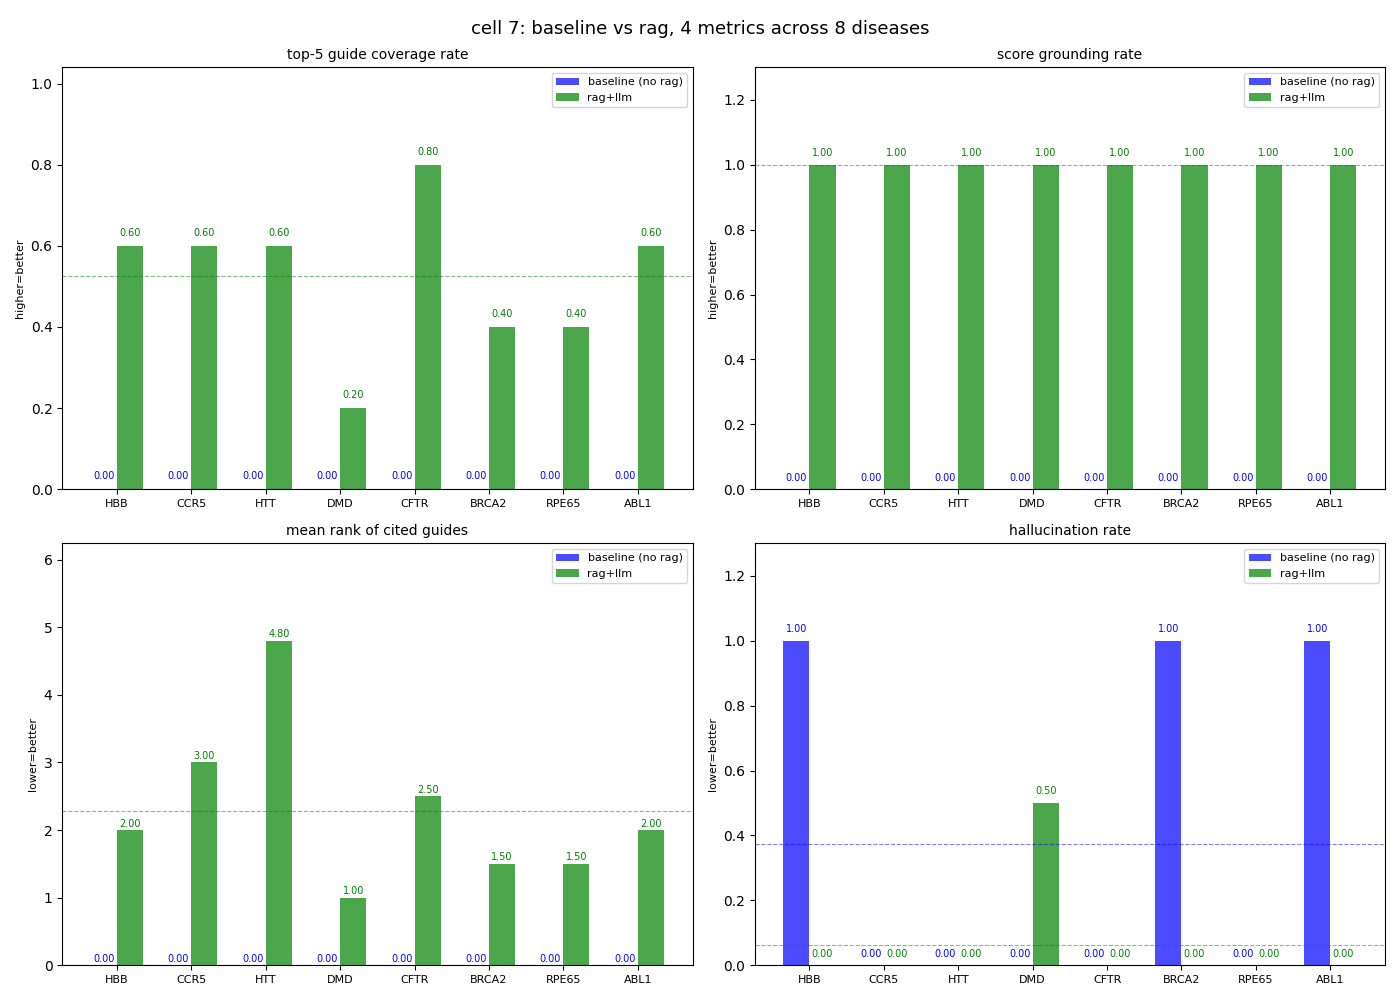

cell 7 done


In [7]:
#metrics for eval
BASE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG-2.0"
DATA_DIR=os.path.join(BASE_DIR,"Data")
RESULTS_DIR=os.path.join(BASE_DIR,"Results")
MULTI_DIR=os.path.join(DATA_DIR,"multi_disease")
DISEASE_FILES=[
    "sickle_cell_anemia.json",
    "hiv_infection.json",
    "huntingtons_disease.json",
    "duchenne_muscular_dystrophy.json",
    "cystic_fibrosis.json",
    "breast_cancer.json",
    "leber_congenital_amaurosis.json",
    "chronic_myeloid_leukemia.json",
]

def load_disease_result(fname):
    path=os.path.join(MULTI_DIR,fname)
    if not os.path.exists(path):
        alt=os.path.join(DATA_DIR,"sickle_cell_anemia.json")
        if os.path.exists(alt):
            with open(alt,encoding="utf-8") as f:
                return json.load(f)
        with open(os.path.join(DATA_DIR,"ranked_genes.json"),encoding="utf-8") as f:
            ranked_data=json.load(f)
        with open(os.path.join(DATA_DIR,"ranked_guides.json"),encoding="utf-8") as f:
            guides_data=json.load(f)
        with open(os.path.join(DATA_DIR,"llm_baseline_output.json"),encoding="utf-8") as f:
            baseline_data=json.load(f)
        with open(os.path.join(DATA_DIR,"rag_output.json"),encoding="utf-8") as f:
            rag_data=json.load(f)
        return {
            "disease":ranked_data["disease_name"],
            "top_genes":ranked_data["top_genes"],
            "guides":guides_data["guides"],
            "baseline_response":baseline_data["llm_response"],
            "rag_response":rag_data["rag_response"],
        }
    with open(path,encoding="utf-8") as f:
        return json.load(f)

def extract_sequences(text):
    return set(re.findall(r'\b[ACGT]{20}\b',text.upper()))
def score_top5_coverage(response,guides,top_k=5):
    #frac of top k ranked guides cited in response
    top_seqs=[g["guide_sequence"].upper() for g in guides[:top_k]]
    cited=extract_sequences(response)
    matched=sum(1 for s in top_seqs if s in cited)
    return round(matched/top_k,2)
def score_score_grounding(response,guides):
    #did response cite a score matching actual xgb scores
    real_scores=set(str(g["xgb_score"]) for g in guides)
    found_scores=set(re.findall(r'0\.\d{3,4}',response))
    return 1 if found_scores&real_scores else 0
def score_mean_cited_rank(response,guides):
    #mean rank pos of cited sequences lower=better
    cited=extract_sequences(response)
    if not cited:
        return 0.0
    ranks=[]
    for i,g in enumerate(guides,1):
        if g["guide_sequence"].upper() in cited:
            ranks.append(i)
    if not ranks:
        return 0.0
    return round(np.mean(ranks),2)
def score_hallucination(response,guides):
    #frac of cited sequences not in ranked list lower=better
    real_seqs=set(g["guide_sequence"].upper() for g in guides)
    cited=extract_sequences(response)
    if not cited:
        return 0.0
    hallucinated=[s for s in cited if s not in real_seqs]
    return round(len(hallucinated)/len(cited),2)

#compute metrics
diseases=[]
baseline_scores={m:[] for m in ["top5_coverage","score_grounding","mean_cited_rank","hallucination"]}
rag_scores={m:[] for m in ["top5_coverage","score_grounding","mean_cited_rank","hallucination"]}
for fname in DISEASE_FILES:
    result=load_disease_result(fname)
    guides=result["guides"]
    top_genes=result["top_genes"]
    baseline=result["baseline_response"]
    rag=result["rag_response"]
    diseases.append(top_genes[0]["gene_symbol"])
    baseline_scores["top5_coverage"].append(score_top5_coverage(baseline,guides))
    baseline_scores["score_grounding"].append(score_score_grounding(baseline,guides))
    baseline_scores["mean_cited_rank"].append(score_mean_cited_rank(baseline,guides))
    baseline_scores["hallucination"].append(score_hallucination(baseline,guides))
    rag_scores["top5_coverage"].append(score_top5_coverage(rag,guides))
    rag_scores["score_grounding"].append(score_score_grounding(rag,guides))
    rag_scores["mean_cited_rank"].append(score_mean_cited_rank(rag,guides))
    rag_scores["hallucination"].append(score_hallucination(rag,guides))
print("metrics computed across 8 diseases")
print(f"\n{'gene':<8} {'b_cov':>5} {'r_cov':>5} {'b_scr':>5} {'r_scr':>5} {'b_r1':>5} {'r_r1':>5} {'b_hal':>5} {'r_hal':>5}")
for i,d in enumerate(diseases):
    print(f"{d:<8}"
          f"{baseline_scores['top5_coverage'][i]:>5} {rag_scores['top5_coverage'][i]:>5}"
          f"{baseline_scores['score_grounding'][i]:>5} {rag_scores['score_grounding'][i]:>5}"
          f"{baseline_scores['mean_cited_rank'][i]:>5} {rag_scores['mean_cited_rank'][i]:>5}"
          f"{baseline_scores['hallucination'][i]:>5} {rag_scores['hallucination'][i]:>5}")

print(f"\naverage across 8 diseases:")
for m in ["top5_coverage","score_grounding","mean_cited_rank","hallucination"]:
    b_avg=round(np.mean(baseline_scores[m]),2)
    r_avg=round(np.mean(rag_scores[m]),2)
    print(f"{m}: baseline={b_avg} | rag={r_avg}")

#visualization
x=np.arange(len(diseases))
width=0.35
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle("cell 7: baseline vs rag, 4 metrics across 8 diseases",fontsize=13)
metric_configs=[
    ("top5_coverage","top-5 guide coverage rate","higher=better"),
    ("score_grounding","score grounding rate","higher=better"),
    ("mean_cited_rank","mean rank of cited guides","lower=better"),
    ("hallucination","hallucination rate","lower=better"),]

for ax,(metric,title,ylabel) in zip(axes.flat,metric_configs):
    b_vals=baseline_scores[metric]
    r_vals=rag_scores[metric]
    bars1=ax.bar(x-width/2,b_vals,width,label="baseline (no rag)",color="blue",alpha=0.7)
    bars2=ax.bar(x+width/2,r_vals,width,label="rag+llm",color="green",alpha=0.7)
    for bar in bars1:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,h+0.02,f"{h:.2f}",ha="center",va="bottom",fontsize=7,color="blue")
    for bar in bars2:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,h+0.02,f"{h:.2f}",ha="center",va="bottom",fontsize=7,color="green")
    ax.set_xticks(x)
    ax.set_xticklabels(diseases,fontsize=8)
    max_val=max(max(b_vals),max(r_vals)) if max(b_vals+r_vals)>0 else 1
    ax.set_ylim(0,max_val*1.3)
    ax.set_title(title,fontsize=10)
    ax.set_ylabel(ylabel,fontsize=8)
    ax.legend(fontsize=8)
    ax.axhline(y=np.mean(b_vals),color="blue",linestyle="--",linewidth=0.8,alpha=0.5)
    ax.axhline(y=np.mean(r_vals),color="green",linestyle="--",linewidth=0.8,alpha=0.5)
plt.tight_layout()
plot_out=os.path.join(RESULTS_DIR,"cell7_metrics_comparison.png")
plt.savefig(plot_out,dpi=100)
plt.close()
display(Image(filename=plot_out))
print("cell 7 done")